<a href="https://colab.research.google.com/github/PrachiKumar298/MLLab/blob/main/mllab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

Iris

In [ ]:
# Column names as per UCI IRIS dataset
columns = [
"sepal_length",
"sepal_width",
"petal_length",
"petal_width",
"species"
]

In [ ]:
# Load the IRIS Dataset using scikit-learn's built-in function
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=columns[:-1])
df['species'] = iris.target_names[iris.target]


In [ ]:
# Separate features and target
X = df.drop("species", axis=1)
y = df["species"]

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


K Means Clustering

In [ ]:
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels


Text(0, 0.5, 'Feature 2')

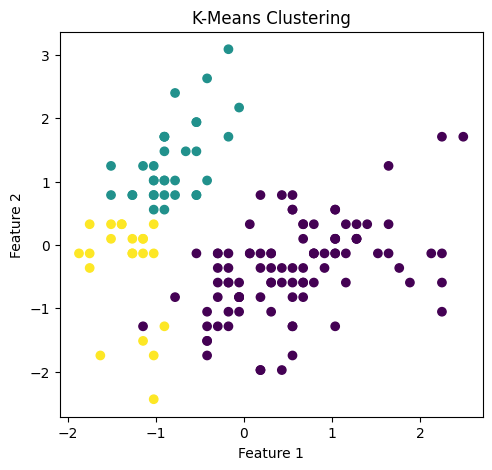

In [ ]:
# Visualization of Clusters
plt.figure(figsize=(12,5))
# KMeans Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0],
X_scaled[:,1],
c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")


In [ ]:
# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("\nK-Means Silhouette Score:", kmeans_silhouette)



K-Means Silhouette Score: 0.4798814508199817


Hierarchial Clustering

In [ ]:
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels_iris = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster_Iris'] = hierarchical_labels_iris

In [ ]:
# Evaluate Hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels_iris)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)

Hierarchical Clustering Silhouette Score: 0.4466890410285909


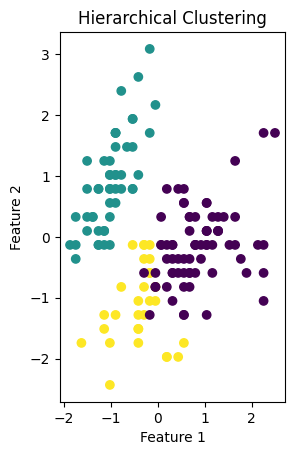

In [ ]:
# Hierarchical Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0],
X_scaled[:,1],
c=hierarchical_labels_iris, cmap='viridis')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


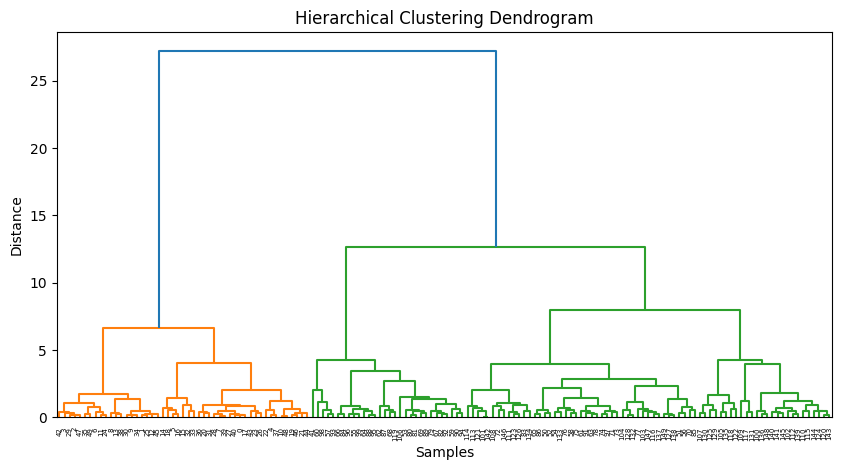

In [ ]:
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

# Instantiate DBSCAN with eps=0.5 and min_samples=5
dbscan_iris = DBSCAN(eps=0.5, min_samples=5)

# Fit DBSCAN to X_scaled and get cluster labels
dbscan_iris_labels = dbscan_iris.fit_predict(X_scaled)


In [ ]:
# Evaluation
dbscan_iris_silhouette = silhouette_score(X_scaled, dbscan_iris_labels)
print("DBSCAN Silhouette Score (Iris):", dbscan_iris_silhouette)

DBSCAN Silhouette Score (Iris): 0.35651648142700726


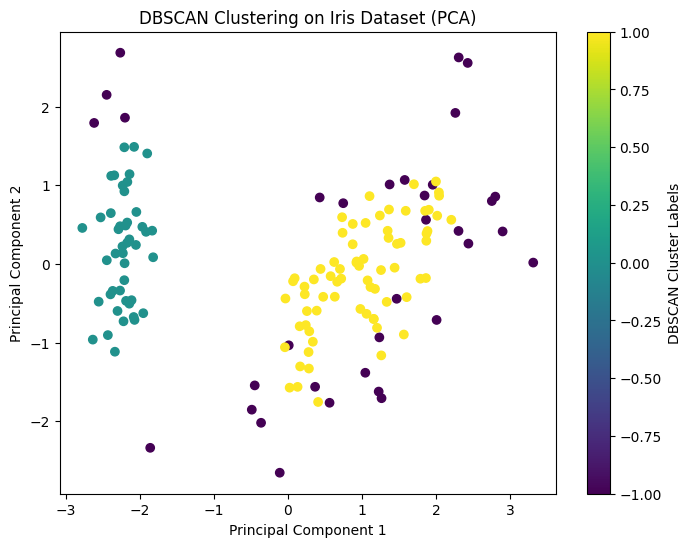

In [ ]:
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_iris_pca[:, 0],
            X_iris_pca[:, 1],
            c=dbscan_iris_labels, cmap='viridis')
plt.title('DBSCAN Clustering on Iris Dataset (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='DBSCAN Cluster Labels')
plt.show()

DIANA

In [ ]:
def custom_diana(data, max_clusters):
    n_samples = data.shape[0]
    # Initialize with all data points in a single cluster (cluster 0)
    labels = np.zeros(n_samples, dtype=int)
    cluster_map = {0: list(range(n_samples))}
    next_cluster_id = 1
    while len(cluster_map) < max_clusters:
        # Find the 'loosest' cluster
        loosest_cluster_id = -1
        max_inertia = -1
        for cluster_id, indices in cluster_map.items():
            if len(indices) > 1: # Only consider clusters with more than one sample for splitting
                current_cluster_data = data[indices]
                # Fit KMeans with n_clusters=1 to find inertia of current cluster
                kmeans_single = KMeans(n_clusters=1, random_state=42, n_init='auto')
                kmeans_single.fit(current_cluster_data)
                if kmeans_single.inertia_ > max_inertia:
                    max_inertia = kmeans_single.inertia_
                    loosest_cluster_id = cluster_id
        if loosest_cluster_id == -1: # No cluster with more than one sample could be split
            break
        # Split the loosest cluster
        loosest_indices = cluster_map[loosest_cluster_id]
        loosest_data = data[loosest_indices]
        kmeans_split = KMeans(n_clusters=2, random_state=42, n_init='auto')
        split_labels = kmeans_split.fit_predict(loosest_data)
        # Assign new labels to the split clusters
        new_cluster_indices_1 = [loosest_indices[i] for i, label in enumerate(split_labels) if label == 0]
        new_cluster_indices_2 = [loosest_indices[i] for i, label in enumerate(split_labels) if label == 1]
        # Remove old cluster and add new ones
        del cluster_map[loosest_cluster_id]
        if new_cluster_indices_1:
            cluster_map[loosest_cluster_id] = new_cluster_indices_1
            for idx in new_cluster_indices_1:
                labels[idx] = loosest_cluster_id
        if new_cluster_indices_2:
            cluster_map[next_cluster_id] = new_cluster_indices_2
            for idx in new_cluster_indices_2:
                labels[idx] = next_cluster_id
            next_cluster_id += 1
    return labels
print("custom_diana function defined successfully.")

custom_diana function defined successfully.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # KMeans is used internally by custom_diana

# Re-define columns as it was also in a non-executed cell
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

# Re-load the IRIS Dataset and create DataFrame as its cell was not executed
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=columns[:-1])
df['species'] = iris.target_names[iris.target]

# Separate features as its cell was not executed
X = df.drop("species", axis=1)

# Feature Scaling as its cell was not executed
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply custom_diana as requested in the subtask
diana_iris_labels = custom_diana(X_scaled, max_clusters=3)
print("First 5 DIANA cluster labels for Iris dataset:")
print(diana_iris_labels[:5])

First 5 DIANA cluster labels for Iris dataset:
[1 1 1 1 1]


In [ ]:
from sklearn.metrics import silhouette_score
diana_iris_silhouette = silhouette_score(X_scaled, diana_iris_labels)
print("DIANA Silhouette Score (Iris):", diana_iris_silhouette)

DIANA Silhouette Score (Iris): 0.45663380641237455


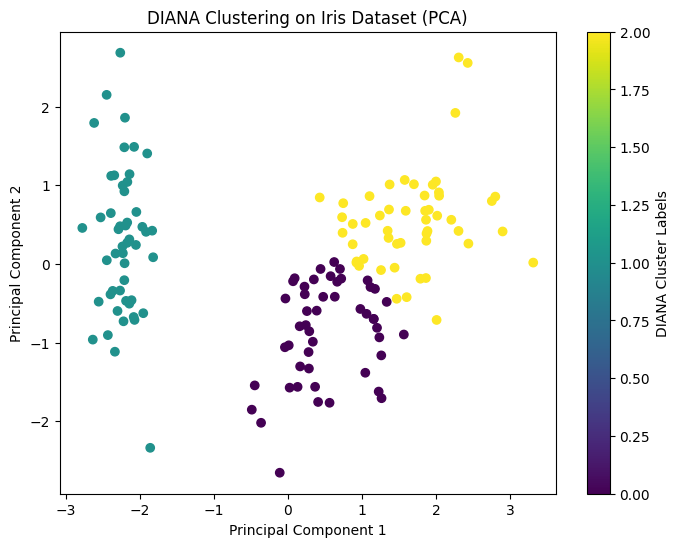

In [ ]:
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_scaled)

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X_iris_pca[:, 0],
            X_iris_pca[:, 1],
            c=diana_iris_labels, cmap='viridis')
plt.title('DIANA Clustering on Iris Dataset (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='DIANA Cluster Labels')
plt.show()

Breast Cancer Dataset

In [ ]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()
X_bc = breast_cancer.data
y_bc = breast_cancer.target

print(f"Features shape (X_bc): {X_bc.shape}")
print(f"Target shape (y_bc): {y_bc.shape}")

Features shape (X_bc): (569, 30)
Target shape (y_bc): (569,)


In [ ]:
scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

print(f"Shape of scaled Breast Cancer data (X_bc_scaled): {X_bc_scaled.shape}")

Shape of scaled Breast Cancer data (X_bc_scaled): (569, 30)


K Means Clustering

In [ ]:
kmeans_bc = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_bc_labels = kmeans_bc.fit_predict(X_bc_scaled)

print("First 5 K-Means cluster labels for Breast Cancer dataset:")
print(kmeans_bc_labels[:5])

First 5 K-Means cluster labels for Breast Cancer dataset:
[0 0 0 0 0]


Text(0, 0.5, 'Principal Component 2')

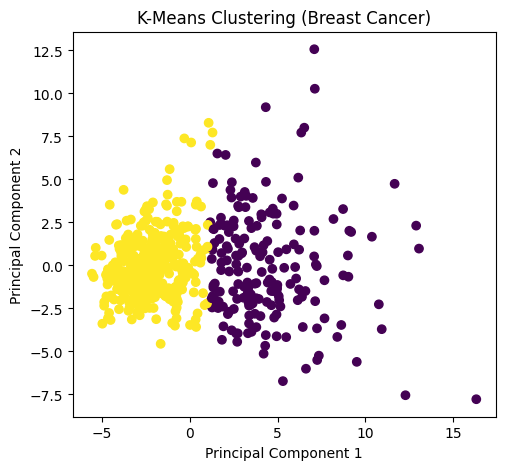

In [ ]:

#K means clustering visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_bc_pca = pca.fit_transform(X_bc_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_bc_pca[:, 0],
            X_bc_pca[:, 1],
            c=kmeans_bc_labels, cmap='viridis')
plt.title('K-Means Clustering (Breast Cancer)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

In [ ]:
kmeans_bc_silhouette = silhouette_score(X_bc_scaled, kmeans_bc_labels)
print("K-Means Silhouette Score (Breast Cancer):", kmeans_bc_silhouette)

K-Means Silhouette Score (Breast Cancer): 0.3447344346611054


Hierarchial Clustering

In [ ]:
hierarchical_bc = AgglomerativeClustering(n_clusters=2)
hierarchical_bc_labels = hierarchical_bc.fit_predict(X_bc_scaled)
print("First 5 Hierarchical cluster labels for Breast Cancer dataset:")
print(hierarchical_bc_labels[:5])

First 5 Hierarchical cluster labels for Breast Cancer dataset:
[0 0 0 0 0]


In [ ]:
hierarchical_bc_silhouette = silhouette_score(X_bc_scaled, hierarchical_bc_labels)
print("Hierarchical Clustering Silhouette Score (Breast Cancer):", hierarchical_bc_silhouette)

Hierarchical Clustering Silhouette Score (Breast Cancer): 0.33938477753669855


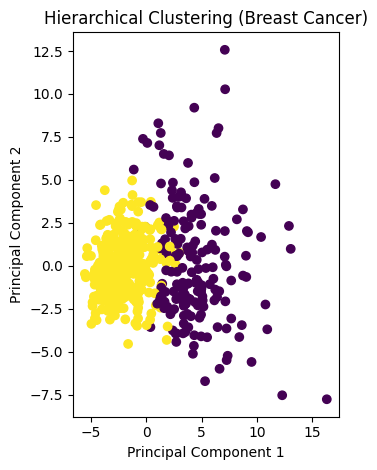

In [ ]:
# Hierarchial Clustering Visualization
plt.subplot(1, 2, 2)
plt.scatter(X_bc_pca[:, 0],
            X_bc_pca[:, 1],
            c=hierarchical_bc_labels, cmap='viridis')
plt.title('Hierarchical Clustering (Breast Cancer)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

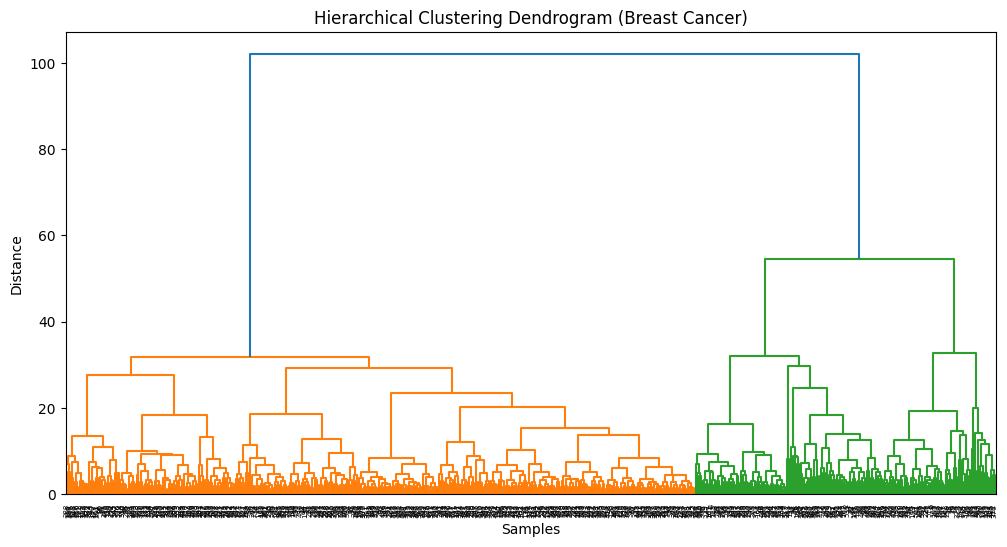

In [ ]:
linked_bc = linkage(X_bc_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked_bc)
plt.title("Hierarchical Clustering Dendrogram (Breast Cancer)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

dbscan_bc = DBSCAN(eps=2.5, min_samples=30)
dbscan_bc_labels = dbscan_bc.fit_predict(X_bc_scaled)

print("First 5 DBSCAN cluster labels for Breast Cancer dataset:")
print(dbscan_bc_labels[:5])

First 5 DBSCAN cluster labels for Breast Cancer dataset:
[-1 -1 -1 -1 -1]


In [ ]:
dbscan_bc_silhouette = silhouette_score(X_bc_scaled, dbscan_bc_labels)
print("DBSCAN Silhouette Score (Breast Cancer):", dbscan_bc_silhouette)

DBSCAN Silhouette Score (Breast Cancer): 0.1220815560134896


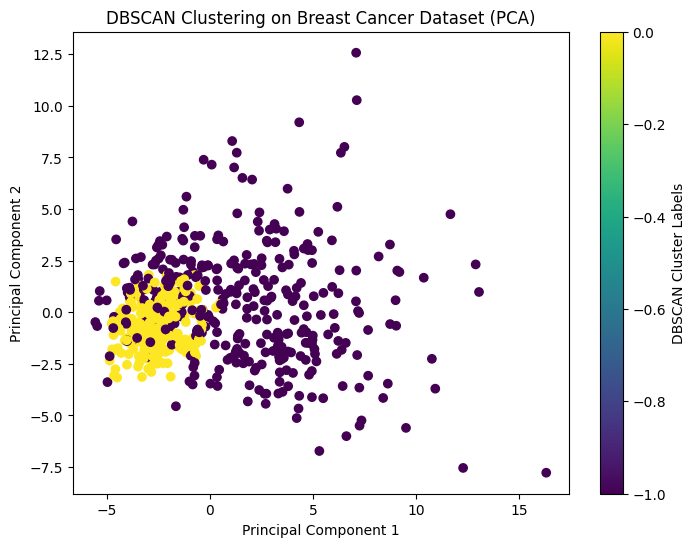

In [ ]:
pca_bc = PCA(n_components=2)
X_bc_pca = pca_bc.fit_transform(X_bc_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_bc_pca[:, 0],
            X_bc_pca[:, 1],
            c=dbscan_bc_labels, cmap='viridis')
plt.title('DBSCAN Clustering on Breast Cancer Dataset (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='DBSCAN Cluster Labels')
plt.show()

Diana

In [ ]:
diana_bc_labels = custom_diana(X_bc_scaled, max_clusters=2)
print(f"X_bc_scaled shape: {X_bc_scaled.shape}")
print("First 5 DIANA cluster labels for Breast Cancer dataset:")
print(diana_bc_labels[:5])

First 5 DIANA cluster labels for Breast Cancer dataset:
[0 0 0 0 0]


In [ ]:
diana_bc_silhouette = silhouette_score(X_bc_scaled, diana_bc_labels)
print("DIANA Silhouette Score (Breast Cancer):", diana_bc_silhouette)

DIANA Silhouette Score (Breast Cancer): 0.3447344346611054


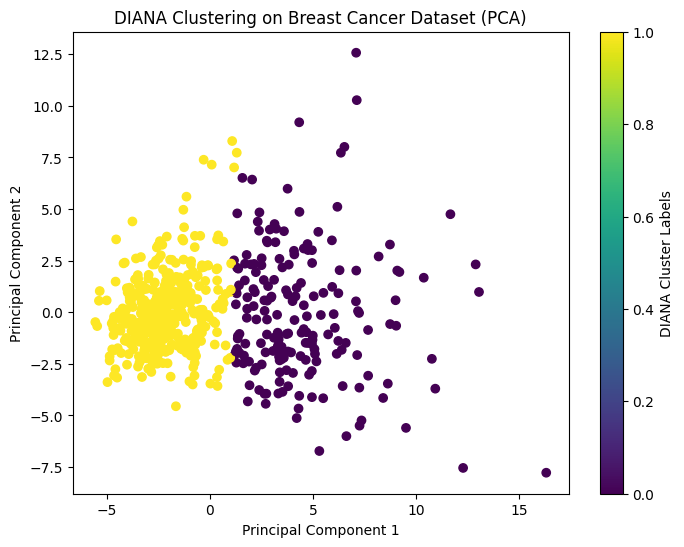

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming pca_bc and X_bc_pca are already defined from previous steps
# If not, they would be defined as:
# pca_bc = PCA(n_components=2)
# X_bc_pca = pca_bc.fit_transform(X_bc_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_bc_pca[:, 0],
            X_bc_pca[:, 1],
            c=diana_bc_labels, cmap='viridis')
plt.title('DIANA Clustering on Breast Cancer Dataset (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='DIANA Cluster Labels')
plt.show()